# 1. Perkenalan Dataset

Sumber Dataset: Kaggle (Public Repository) - Steam Database 2026 Fixed

Dataset ini merupakan versi yang telah dibersihkan dan dikoreksi dari dataset Steam Games asli (Fronkon Games). Dataset ini memuat informasi  mengenai game di platform Steam yang diperbarui hingga Januari 2026, mencakup. Harga, tanggal rilis, genre, dan estimasi kepemilikan (estimated owners), ulasan, waktu bermain (playtime), dan puncak pemain aktif bersamaan (Peak CCU).

# 2. Import Library

In [3]:
!pip install pandas matplotlib seaborn scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 3. Memuat Dataset

In [4]:
df = pd.read_csv('../steam_dataset_raw/steam_cleaned_2026.csv')
display(df.head())

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...
3,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...
4,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,...,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...


# 4. Exploratory Data Analysis (EDA)

<class 'pandas.DataFrame'>
RangeIndex: 114172 entries, 0 to 114171
Data columns (total 38 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       114172 non-null  int64  
 1   Name                        114172 non-null  str    
 2   Release date                114172 non-null  str    
 3   Estimated owners            114172 non-null  str    
 4   Peak CCU                    114172 non-null  int64  
 5   Required age                114172 non-null  int64  
 6   Price                       114172 non-null  float64
 7   Discount                    114172 non-null  int64  
 8   DLC count                   114172 non-null  int64  
 9   About the game              113902 non-null  str    
 10  Supported languages         114172 non-null  str    
 11  Full audio languages        114172 non-null  str    
 12  Reviews                     12029 non-null   str    
 13  Header image             

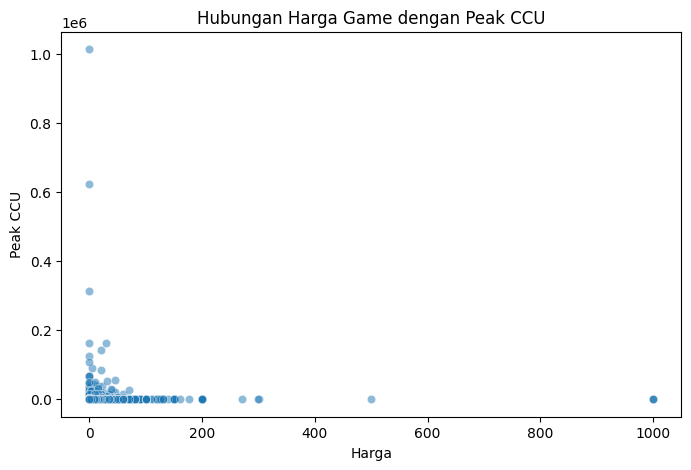

In [5]:
# Cek informasi dasar dan missing values
df.info()
print("\nJumlah Missing Values:")
print(df.isnull().sum())

# Relasi antara Harga dan Peak CCU (Concurrent Users)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Price', y='Peak CCU', alpha=0.5)
plt.title('Hubungan Harga Game dengan Peak CCU')
plt.xlabel('Harga')
plt.ylabel('Peak CCU')
plt.show()

# 5.Data Preprocessing

In [6]:
# 1. Drop kolom yang tidak relevan untuk pemodelan ML
cols_to_drop = ['Header image', 'Website', 'Support url', 'Support email', 'Notes', 'Screenshots']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Menangani Missing Values dan Mengisi nilai kosong di kategori dengan 'Unknown'
df_clean['Developers'] = df_clean['Developers'].fillna('Unknown')
df_clean['Publishers'] = df_clean['Publishers'].fillna('Unknown')

# Menghapus baris jika ada nilai numerik penting yang kosong
df_clean = df_clean.dropna(subset=['Price', 'Positive', 'Negative'])

# 3. Normalisasi Fitur Numerik 
scaler = MinMaxScaler()
num_cols = ['Price', 'Peak CCU', 'Positive', 'Negative', 'Average playtime forever']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# Cek hasil akhir
print("Dimensi setelah preprocessing:", df_clean.shape)
display(df_clean.head())

Dimensi setelah preprocessing: (114172, 32)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0.000000e+00,0,0.00524,65,0,"Springtime, April: when the cherry trees come ...",...,231,0.000002,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0.000000e+00,0,0.00499,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0.000000,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,9.862555e-07,0,0.00899,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0.000000,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN
3,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0.000000e+00,0,0.00499,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0.000000,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN
4,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0.000000e+00,0,0.01399,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,...,0,0.000000,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN
